In [1]:
from knn import KNNClassifier
from fisher import FisherClassifier

In [2]:
import pandas as pd
from sklearn.datasets import load_iris

# Load as a Scikit-Learn Bunch object
iris = load_iris()

# Convert to a standard Pandas DataFrame for easy analysis
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target  # Add the numeric labels (0, 1, 2)
df['species'] = df['target'].map({i: name for i, name in enumerate(iris.target_names)})

print(df.head())
print(df.info())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             

In [3]:
df_train = df.sample(frac=0.8, random_state=42)  # 80% for training
df_test = df.drop(df_train.index)  # Remaining 20% for testing

In [4]:
knn_classifier = KNNClassifier(k=3)

knn_classifier.fit(df_train[iris.feature_names].values, df_train['target'].values)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       0.92      1.00      0.96        11
   virginica       1.00      0.92      0.96        12

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

[[ 7  0  0]
 [ 0 11  0]
 [ 0  1 11]]


<Axes: >

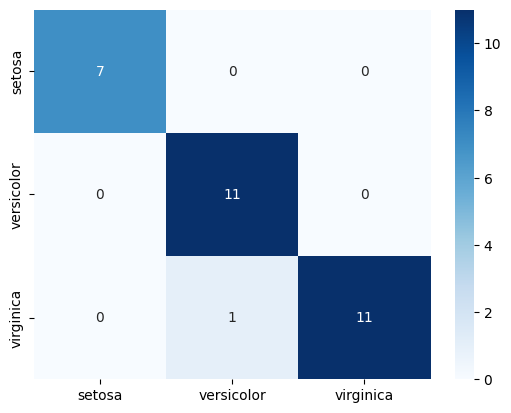

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred_knn = knn_classifier.predict(df_test[iris.feature_names].values)
print(classification_report(df_test['target'].values, y_pred_knn, target_names=iris.target_names))
print(confusion_matrix(df_test['target'].values, y_pred_knn))
sns.heatmap(
    confusion_matrix(
        df_test['target'].values,
        y_pred_knn
    ),
    annot=True, 
    fmt='d',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    cmap='Blues'
)

In [6]:
fisher_classifier = FisherClassifier()

fisher_classifier.fit(df_train[iris.feature_names].values, df_train['target'].values)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       0.77      0.91      0.83        11
   virginica       0.90      0.75      0.82        12

    accuracy                           0.87        30
   macro avg       0.89      0.89      0.88        30
weighted avg       0.88      0.87      0.87        30

[[ 7  0  0]
 [ 0 10  1]
 [ 0  3  9]]


<Axes: >

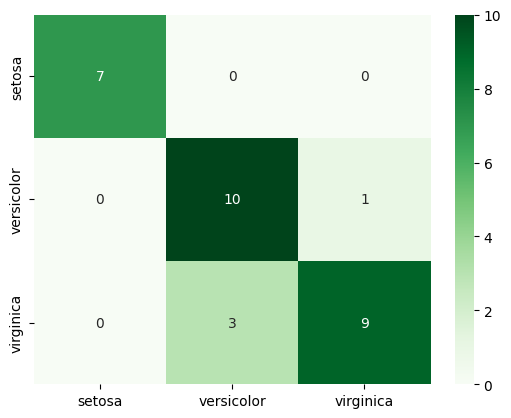

In [7]:
y_pred_fisher = fisher_classifier.predict(df_test[iris.feature_names].values)
print(classification_report(df_test['target'].values, y_pred_fisher, target_names=iris.target_names))
print(confusion_matrix(df_test['target'].values, y_pred_fisher))
sns.heatmap(
    confusion_matrix(
        df_test['target'].values,
        y_pred_fisher
    ),
    annot=True, 
    fmt='d',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    cmap='Greens'
)